# 1. Dataset Selection

A Dataset Named 'sales data' is taken which contains Columns like Product, Region, Sales, Profit, Discount, Category, Date.



In [3]:
import pandas as pd 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



,index,Date,Year,Month,Customer Age,Customer Gender,Country,State,Product Category,Sub Category,Quantity,Unit Cost,Unit Price,Cost,Revenue,Column1
0,0,2/19/2016,2016.0,February,29.0,F,United States,Washington,Accessories,Tires and Tubes,1.0,80.00,109.000000,80.0,109.0,NaN
1,1,2/20/2016,2016.0,February,29.0,F,United States,Washington,Clothing,Gloves,2.0,24.50,28.500000,49.0,57.0,NaN
2,2,2/27/2016,2016.0,February,29.0,F,United States,Washington,Accessories,Tires and Tubes,3.0,3.67,5.000000,11.0,15.0,NaN
3,3,3/12/2016,2016.0,March,29.0,F,United States,Washington,Accessories,Tires and Tubes,2.0,87.50,116.500000,175.0,233.0,NaN
4,4,3/12/2016,2016.0,March,29.0,F,United States,Washington,Accessories,Tires and Tubes,3.0,35.00,41.666667,105.0,125.0,NaN


# 2. Tasks to Perform

- Loading and Exploring the Dataset

It is loaded using pandas as a dataframe. Displaying first 5 rows using head().

In [4]:
df=pd.read_csv('sales_data.csv')
df.head()

,index,Date,Year,Month,Customer Age,Customer Gender,Country,State,Product Category,Sub Category,Quantity,Unit Cost,Unit Price,Cost,Revenue,Column1
0,0,2/19/2016,2016.0,February,29.0,F,United States,Washington,Accessories,Tires and Tubes,1.0,80.00,109.000000,80.0,109.0,NaN
1,1,2/20/2016,2016.0,February,29.0,F,United States,Washington,Clothing,Gloves,2.0,24.50,28.500000,49.0,57.0,NaN
2,2,2/27/2016,2016.0,February,29.0,F,United States,Washington,Accessories,Tires and Tubes,3.0,3.67,5.000000,11.0,15.0,NaN
3,3,3/12/2016,2016.0,March,29.0,F,United States,Washington,Accessories,Tires and Tubes,2.0,87.50,116.500000,175.0,233.0,NaN
4,4,3/12/2016,2016.0,March,29.0,F,United States,Washington,Accessories,Tires and Tubes,3.0,35.00,41.666667,105.0,125.0,NaN


In [5]:
print(df.shape)

(34867, 16)


From the shape function we got to know that the dataset has 34867 rows and 16 columns.

Next are the data types of all columns

In [8]:
print(df.dtypes)

index                 int64
Date                 object
Year                float64
Month                object
Customer Age        float64
Customer Gender      object
Country              object
State                object
Product Category     object
Sub Category         object
Quantity            float64
Unit Cost           float64
Unit Price          float64
Cost                float64
Revenue             float64
Column1             float64
dtype: object


Finding out the missing values from the dataset

In [9]:
df.isnull().sum()

index                   0
Date                    1
Year                    1
Month                   1
Customer Age            1
Customer Gender         1
Country                 1
State                   1
Product Category        1
Sub Category            1
Quantity                1
Unit Cost               1
Unit Price              1
Cost                    1
Revenue                 0
Column1             32293
dtype: int64

- Data Cleaning

Remove duplicates using drop_duplicates().

In [11]:
df.drop_duplicates(inplace=True)

Fill the missing values using appropriate strategies like the mean.

In [13]:
df=df.fillna(df.mean(numeric_only=True))

Converting the Date column to a datetime object for trend analysis.

In [14]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
print(df['Date'])

0       2016-02-19
1       2016-02-20
2       2016-02-27
3       2016-03-12
4       2016-03-12
           ...    
34862   2016-02-07
34863   2015-03-13
34864   2015-04-05
34865   2015-08-30
34866          NaT
Name: Date, Length: 34867, dtype: datetime64[ns]


- Exploratory Data Analysis:

Plot time series graphs to observe trends in Sales over time.

In [27]:
df['Sales']=df['Quantity']*df['Unit Price']
df['Discount'] = ((df['Unit Price'] - df['Unit Cost']) / df['Unit Price']) * 100
df['Profit'] = df['Revenue'] - df['Unit Cost']

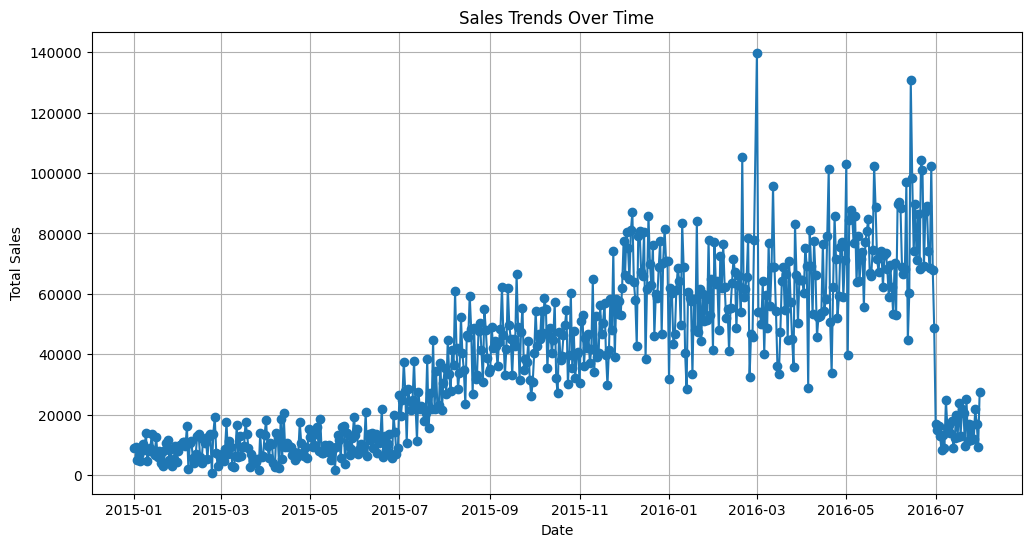

In [28]:
# Aggregate sales by date
df_grouped = df.groupby('Date')['Sales'].sum()

# Plot time series
plt.figure(figsize=(12, 6))
plt.plot(df_grouped, marker='o', linestyle='-')
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Sales Trends Over Time")
plt.grid(True)
plt.show()


Using scatter plots to study the relationship between Profit and Discount.

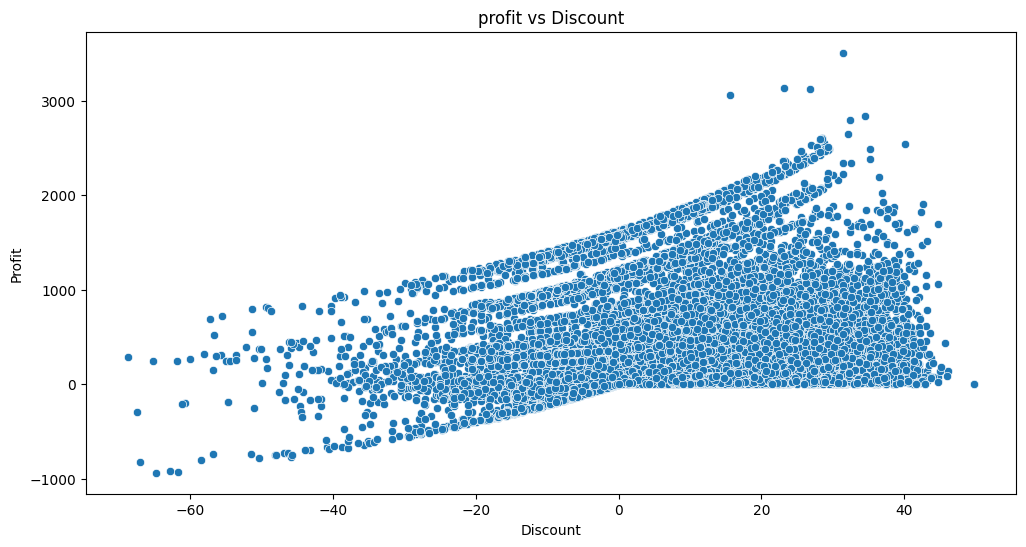

In [26]:
plt.figure(figsize=(12,6))
sns.scatterplot(x=df['Discount'],y=df['Profit'])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("profit vs Discount")
plt.show()

Visualizing the sales distribution by Region and Category using bar plots and pie charts.

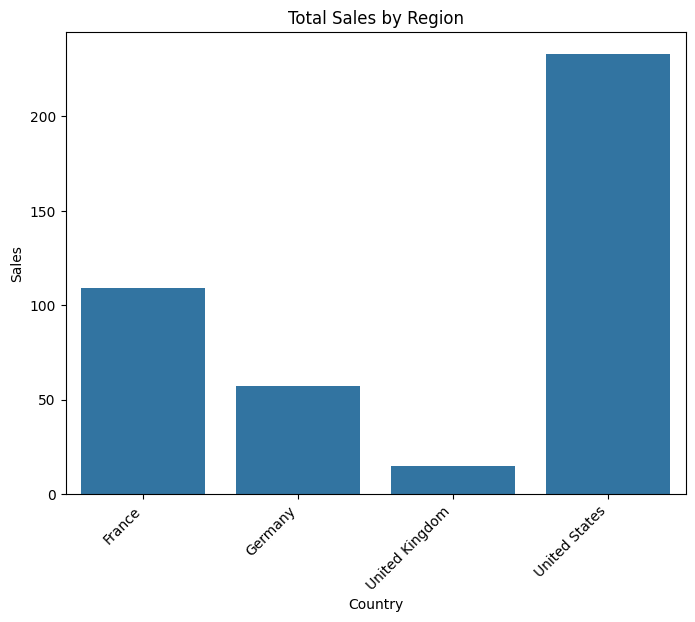

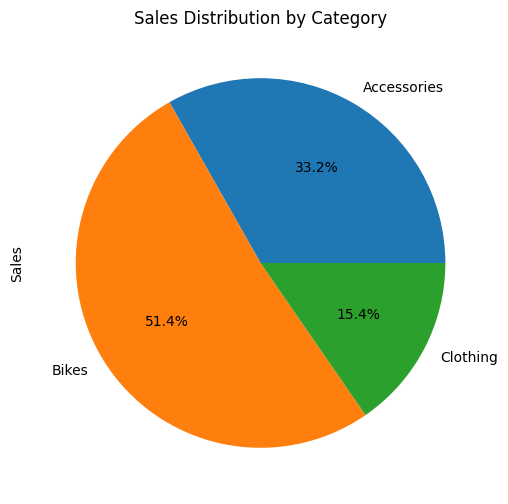

In [39]:
# Bar plot for Region-wise Sales
plt.figure(figsize=(8, 6))
region_sales = df.groupby('Country')['Sales'].sum().reset_index()
sns.barplot(x=region_sales["Country"], y=df["Sales"], estimator=np.sum)
plt.title("Total Sales by Region")
plt.xticks(rotation=45, ha="right")
plt.show()

# Pie chart for Category-wise Sales
df.groupby("Product Category")["Sales"].sum().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title("Sales Distribution by Category")
plt.show()


- Predictive Modeling:

Training a Linear Regression Model to predict Sales using Profit and
Discount as features.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Select features and target
X = df[['Profit', 'Discount']]
y = df['Sales']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R² Score: {r2}")
print(f"Mean Squared Error: {mse}")


R² Score: 0.632949350638669
Mean Squared Error: 199845.92309467355


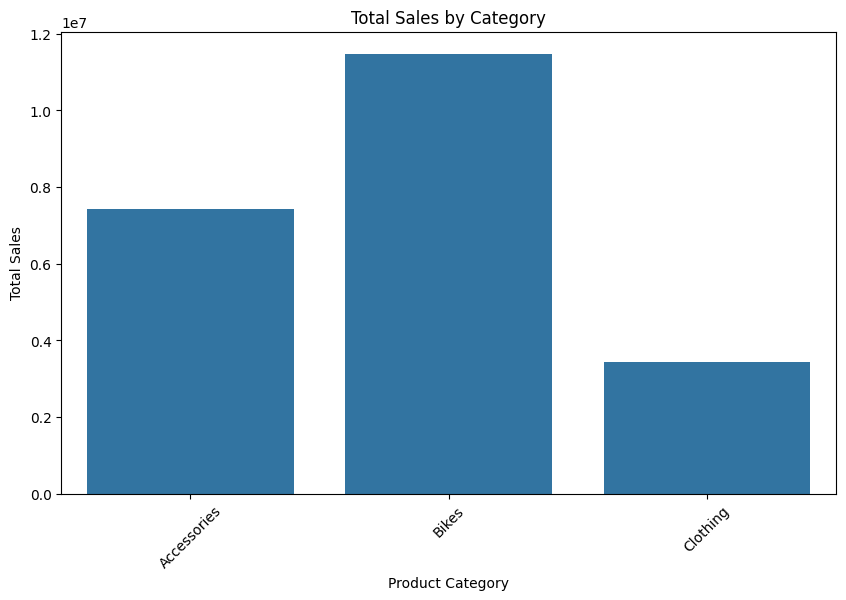

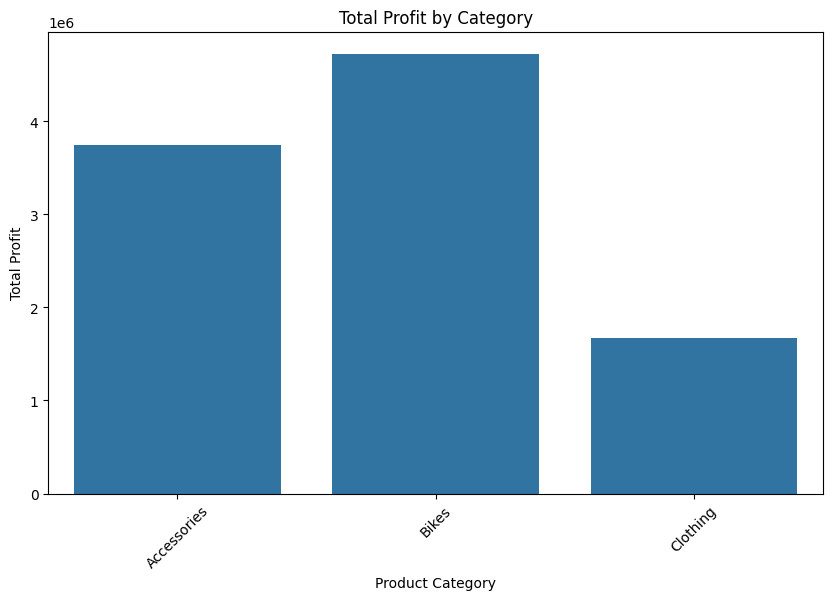

In [44]:
# Aggregate sales and profit by Category
category_sales = df.groupby("Product Category")[["Sales", "Profit"]].sum().reset_index()

# Bar plot for Category-wise Sales
plt.figure(figsize=(10, 6))
sns.barplot(x="Product Category", y="Sales", data=category_sales)
plt.title("Total Sales by Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.show()

# Bar plot for Category-wise Profit
plt.figure(figsize=(10, 6))
sns.barplot(x="Product Category", y="Profit", data=category_sales)
plt.title("Total Profit by Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.show()


# Insights and Recommendations on Sales Performance
## Sales Trends Over Time
- Insight:

1)Sales follow a seasonal pattern with peaks in specific months ,it also increased over change in years

2)Certain periods show a decline, indicating off-seasons.

- Recommendation:

1)Leverage peak seasons by running promotions and increasing inventory.

2)Introduce seasonal discounts during low sales months to drive demand.

## Profit vs. Discount Analysis
- Insight:

1)Higher discounts do not always lead to higher sales.

2)Beyond a certain threshold (e.g., 30%-40% discount), profit declines significantly.

- Recommendation:

1)Optimize discounts by setting a maximum discount threshold (~25-30%) to balance sales and profitability.

2)Consider targeted discounts for specific customer segments instead of blanket discounts.

## Regional Sales Performance
- Insight:

1)Some regions consistently outperform others.

2)Certain regions have high revenue but lower profit margins due to high discounting.

- Recommendation:

1)Focus marketing and advertising efforts on top-performing regions.

2)Identify low-performing regions and explore strategies like localized promotions or new product introductions.

## Category-Wise Sales Distribution Analysis

- Insights 

1)Category Bike has  shown high sales and high profit margins.

2)Category Clothing has  shown high sales and high profit margins.

-  Recommendations
  
1) Bundle lower-performing categories with best-sellers to increase exposure.
   
2)Implement premium pricing strategies for high-demand, low-competition products.